In [1]:
from copy import deepcopy
import pickle
import numpy as np

def align_smooth_scores(preds, time_points, smooth_win=10):
    # cut predicted scores and time_points_german into 8 runs
    cut_index2 = [[0, 22550/25], [22150/25, 32312/25], [36349/25, 48237/25], [47837/25, 57798/25], [58470/25, 70409/25], [70009/25, 85997/25], [89293/25, 97705/25], [97305/25, 117351/25], [120616/25, 123670/25], [123270/25, 141457/25], [145869/25, 149632/25], [149232/25, 152260/25], [154244/25, 178316/25],  [177916/25, 194792/25]]

    time_points_ori = deepcopy(time_points)
    time_points_ori[time_points_ori>=4443] = time_points_ori[time_points_ori>=4443] + (4462-4443)
    time_points_ori[time_points_ori>=4483] = time_points_ori[time_points_ori>=4483] + (4514-4483)
    time_points_ori[time_points_ori>=5177] = time_points_ori[time_points_ori>=5177] + (5210-5177)
    time_points_ori[time_points_ori>=5371] = time_points_ori[time_points_ori>=5371] + (5380-5371)

    # Find time points in the german version. (the frame rate was different from the original movie)
    time_points_german = time_points_ori / (25/(24000/1001))
    
    n_emos = preds.shape[1]
    preds_cut = np.zeros((0,n_emos))
    time_points_german_cut = np.zeros(0)
    for i in range(len(cut_index2)):
        preds_cut = np.concatenate((preds_cut, preds[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1]), :]), 0)
        time_points_german_cut = np.concatenate((time_points_german_cut, time_points_german[(time_points_german >= cut_index2[i][0]) & (time_points_german <= cut_index2[i][1])]), 0)

    # Get time of ratings in German version
    time_ratings = []
    seg_lens = [902,882,876,976,924,878,1084,676]
    for i in range(8):
        tmp = np.arange(0,seg_lens[i],2)
        if (i > 0) and (i < 7): # The first and the last runs only have one segment
            tmp = tmp + cut_index2[i*2-1][0]
            tmp[tmp > cut_index2[i*2-1][1]]  = tmp[tmp > cut_index2[i*2-1][1]] + cut_index2[i*2][0] - cut_index2[i*2-1][1] # Add skipped time
        elif i == 7:
            tmp = tmp + cut_index2[i*2-1][0]
        time_ratings.extend(tmp)
        
    # Resample preds_cut to the same sampling rate of ratings_mean (by average over 2s neighboring to time_ratings)
    preds_cut_resample = np.zeros((3599, n_emos))
    for i in range(3599):
        if np.sum((time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)))==0:
            preds_cut_resample[i,:] = preds_cut_resample[i-1,:]
        else:
            preds_cut_resample[i,:] = np.mean(preds_cut[(time_points_german_cut < (time_ratings[i]+1)) & (time_points_german_cut >= (time_ratings[i]-1)),:], axis=0)

    # Smooth the predicted scores over ts windows
    preds_smoothed = np.zeros(preds_cut_resample.shape)
    for i in range(preds_cut_resample.shape[0]):
        tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
        preds_smoothed[i,:] = np.mean(tmp[np.sum(np.abs(tmp), axis=1)!=0, :], axis=0)
    return preds_smoothed, time_ratings


def smooth_scores(preds_cut_resample, time_ratings, smooth_win=10):
    # Smooth the predicted scores over ts windows
    preds_smoothed = np.zeros(preds_cut_resample.shape)
    for i in range(preds_cut_resample.shape[0]):
        tmp = preds_cut_resample[abs(time_ratings - time_ratings[i]) <= smooth_win//2, :]
        preds_smoothed[i,:] = np.mean(tmp, axis=0)
    return preds_smoothed

In [2]:
import h5py
import pickle
import numpy as np
import os
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Online_human_ratings_danmu\ratings6_sorted_final_12sub.pkl', 'rb') as f:
    human_danmu = pickle.load(f)
    
data_keys = np.arange(0,5756,5)
# data_keys = list(human_danmu.keys())
# time_points_human_danmu = np.zeros(len(data_keys))
human_danmu_mean = np.zeros((len(data_keys), 6))
for i in range(len(data_keys)):
    # time_points_human_danmu[i] = data_keys[i]
    human_danmu_mean[i,:] = np.mean(np.array(human_danmu[data_keys[i]]), axis=1)
    
human_danmu_12 = np.zeros((1152, 6, 12))
for i in range(len(data_keys)):
    # print(data[data_keys[i]])
    for j in range(6):
        for k in range(12):
            human_danmu_12[i,j,k] = human_danmu[data_keys[i]][j][k]
            
path=r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\Lettieri-Forrest\forrest_gump_movie_italian\raw_ratings.mat'
human_movie=np.zeros([12,6,3599])
count = 0
with h5py.File(path,'r') as file:
    for item in file.items():
        # print(item[0])
        tmp = file[item[0]][:][[0,1,3,4,5,2],:] 
        human_movie[count]=tmp
        count += 1
human_movie_mean = np.mean(human_movie, axis=0)
human_movie_mean = human_movie_mean.transpose()

human_movie = human_movie.transpose([2,1,0])
    

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_gpt3_5_turbo.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
llm_danmu = scores_allvideo['forrest_gump']

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Processed_danmu\danmu_Forrest_Gump_downsample.pkl', 'rb') as f:
    danmu_dict = pickle.load(f)
time_ranges = danmu_dict['forrest_gump.csv_time_range']

time_points_llm_danmu = np.zeros(len(time_ranges))
for i in range(len(time_points_llm_danmu)):
    time_points_llm_danmu[i] = np.mean(time_ranges[i])

time_points_human_danmu = time_points_llm_danmu[np.arange(0,5756,5)]
human_danmu_12_aligned = np.zeros((3599,6,12))
for j in range(12):
    human_danmu_12_aligned[:,:,j], _ = align_smooth_scores(human_danmu_12[:,:,j], time_points_human_danmu)
human_danmu_mean_aligned, _ = align_smooth_scores(human_danmu_mean, time_points_human_danmu)

llm_danmu_aligned, time_ratings = align_smooth_scores(llm_danmu, time_points_llm_danmu)

smooth_win=10
human_movie_aligned = np.zeros(human_movie.shape)
for j in range(12):
    human_movie_aligned[:,:,j] = smooth_scores(human_movie[:,:,j], time_ratings)
    
human_movie_mean_aligned = smooth_scores(human_movie_mean, time_ratings)

In [3]:
print(llm_danmu_aligned.shape)

(3599, 6)


In [4]:
llm_danmu_all = np.zeros((3599,6,4))
llm_danmu_all[:,:,0] = llm_danmu_aligned

In [5]:
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_gpt4o.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
llm_danmu_other = scores_allvideo['forrest_gump']
print(llm_danmu_other.shape)
llm_danmu_aligned_other, time_ratings = align_smooth_scores(llm_danmu_other, time_points_llm_danmu)
llm_danmu_all[:,:,1] = llm_danmu_aligned_other

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_kimi.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
llm_danmu_other = scores_allvideo['forrest_gump']
print(llm_danmu_other.shape)
llm_danmu_aligned_other, time_ratings = align_smooth_scores(llm_danmu_other, time_points_llm_danmu)
llm_danmu_all[:,:,2] = llm_danmu_aligned_other

with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-Forrest\Emotion_scores\scores_longMovie_deepseek.pkl', 'rb') as f:
    scores_allvideo = pickle.load(f)
llm_danmu_other = scores_allvideo['forrest_gump']
print(llm_danmu_other.shape)
llm_danmu_aligned_other, time_ratings = align_smooth_scores(llm_danmu_other, time_points_llm_danmu)
llm_danmu_all[:,:,3] = llm_danmu_aligned_other

(5756, 6)
(5756, 6)
(5756, 6)


-37.801053709930905 9.255488948432471e-161
-16.164381285863286 4.828143698540727e-49
2.2256911157850707 0.026406290260046983
21.41136302814966 5.855129945767523e-76
33.0335121875214 4.770280120140689e-137
42.22804369356433 1.0224195469013669e-181
emotion_mean_r: [0.79942795 0.43144379 0.79473547 0.69618097 0.62037391 0.60480783]
emotion_mean_r: [0.66405427 0.25044894 0.76130425 0.60018154 0.563546   0.55736972]
emotion_mean_r: [0.76420181 0.43314655 0.78684557 0.69946439 0.63223008 0.60781553]


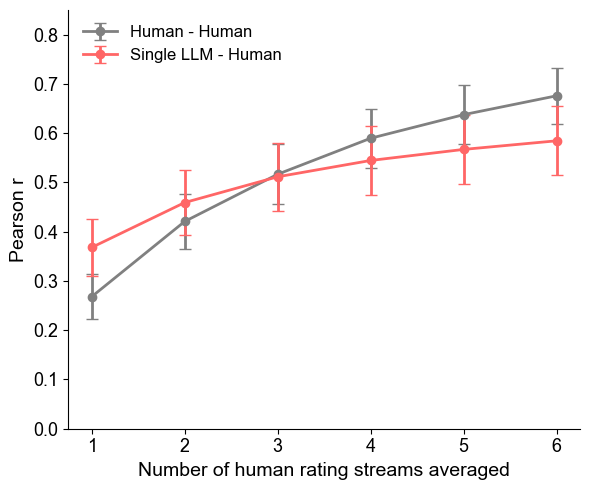

In [6]:
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt

def fisher_r_to_z(r):
    r = np.clip(r, -0.999999, 0.999999)
    return 0.5 * np.log((1 + r) / (1 - r))

def fisher_z_to_r(z):
    return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

def corr(a, b):
    return np.corrcoef(a, b)[0, 1]

# ==================== Parameters ====================
rng = np.random.default_rng(42)
n_splits = 100
n_subjects = 12
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

# max subgroup size is 6 because Human-Human comparison needs two non-overlapping groups
group_sizes = np.arange(1, 7)

# Choose the single LLM used in the main analysis
single_llm_idx = 0   # 改成你的主分析 LLM index，比如 GPT-3.5

single_llm_ts = llm_danmu_all[:, :, single_llm_idx]          # [time, emotion]
avg_llm_ts = np.mean(llm_danmu_all, axis=2)                  # [time, emotion]

# Results: [group_size, emotion, split]
r_human_human = np.zeros((len(group_sizes), 6, n_splits))
r_single_llm_human = np.zeros((len(group_sizes), 6, n_splits))
r_avg_llm_human = np.zeros((len(group_sizes), 6, n_splits))

# ==================== Random subgroup analysis ====================
for gi, k in enumerate(group_sizes):
    for split in range(n_splits):
        subjects = rng.permutation(n_subjects)

        group_a = subjects[:k]
        group_b = subjects[k:2*k]

        for ei in range(6):
            human_a = human_danmu_12_aligned[:, ei, group_a].mean(axis=1)
            human_b = human_danmu_12_aligned[:, ei, group_b].mean(axis=1)

            # Human-Human consistency
            r_human_human[gi, ei, split] = corr(human_a, human_b)

            # Single LLM vs human subgroup
            r1 = corr(single_llm_ts[:, ei], human_a)
            r2 = corr(single_llm_ts[:, ei], human_b)
            r_single_llm_human[gi, ei, split] = fisher_z_to_r(
                np.mean([fisher_r_to_z(r1), fisher_r_to_z(r2)])
            )

            # Averaged LLMs vs human subgroup
            r1 = corr(avg_llm_ts[:, ei], human_a)
            r2 = corr(avg_llm_ts[:, ei], human_b)
            r_avg_llm_human[gi, ei, split] = fisher_z_to_r(
                np.mean([fisher_r_to_z(r1), fisher_r_to_z(r2)])
            )

# ==================== Summarize across emotions ====================
def summarize_over_emotions_and_splits(r_array):
    """
    r_array: [group_size, emotion, split]
    Returns mean and SEM across emotions.
    For each emotion, average over random splits using Fisher z.
    """
    z = fisher_r_to_z(r_array)
    emotion_mean_z = np.mean(z, axis=2)  # [group_size, emotion]
    mean_r = fisher_z_to_r(np.mean(emotion_mean_z, axis=1))
    sem_r = np.std(fisher_z_to_r(emotion_mean_z), axis=1, ddof=1) / np.sqrt(emotion_mean_z.shape[1])
    print('emotion_mean_r:', fisher_z_to_r(emotion_mean_z[-1]))
    return mean_r, sem_r

from scipy import stats
z_human_human = fisher_r_to_z(r_human_human)
z_single_llm_human = fisher_r_to_z(r_single_llm_human)
for i in range(6):
    t, p = stats.ttest_rel(z_human_human[i].reshape(-1), z_single_llm_human[i].reshape(-1))
    print(t, p)

mean_hh, sem_hh = summarize_over_emotions_and_splits(r_human_human)
mean_single, sem_single = summarize_over_emotions_and_splits(r_single_llm_human)
mean_avg, sem_avg = summarize_over_emotions_and_splits(r_avg_llm_human)

# ==================== Plot ====================
matplotlib.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(6, 5))

ax.errorbar(
    group_sizes, mean_hh, yerr=sem_hh,
    marker='o', linewidth=2, capsize=4,
    label='Human - Human', color='gray'
)

ax.errorbar(
    group_sizes, mean_single, yerr=sem_single,
    marker='o', linewidth=2, capsize=4,
    label='Single LLM - Human', color='#ff6666'
)

# ax.errorbar(
#     group_sizes, mean_avg, yerr=sem_avg,
#     marker='o', linewidth=2, capsize=4,
#     label='Averaged LLMs - Human', color='green'
# )

ax.set_xlabel('Number of human rating streams averaged', fontsize=14)
ax.set_ylabel('Pearson r', fontsize=14)
ax.set_xticks(group_sizes)
ax.tick_params(axis='both', labelsize=13)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.legend(
    fontsize=12,
    loc='upper left',
    frameon=False
)

plt.ylim([0, 0.85])
plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/subgroup_size_reliability_curve2.jpg', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
r_human_human.shape

(6, 6, 100)

group_size=1: t=-27.636, raw_p=0.0000
group_size=2: t=-13.513, raw_p=0.0000
group_size=3: t=1.310, raw_p=0.1913
group_size=4: t=12.289, raw_p=0.0000
group_size=5: t=21.784, raw_p=0.0000
group_size=6: t=32.020, raw_p=0.0000

After FDR correction:
group_size=1: adj_p=0.0000 ***
group_size=2: adj_p=0.0000 ***
group_size=3: adj_p=0.1913 
group_size=4: adj_p=0.0000 ***
group_size=5: adj_p=0.0000 ***
group_size=6: adj_p=0.0000 ***
[0.36796951 0.46002408 0.510778   0.54316458 0.5654069  0.58467433] [0.27107432 0.4150937  0.51494061 0.58334194 0.63272897 0.67632972] [ 0.09689519  0.04493038 -0.00416261 -0.04017736 -0.06732208 -0.09165539]
[0.05700891 0.06596032 0.06826701 0.0701357  0.07058084 0.07039821] [0.04639856 0.05909014 0.06131536 0.06035719 0.05910438 0.05668362]


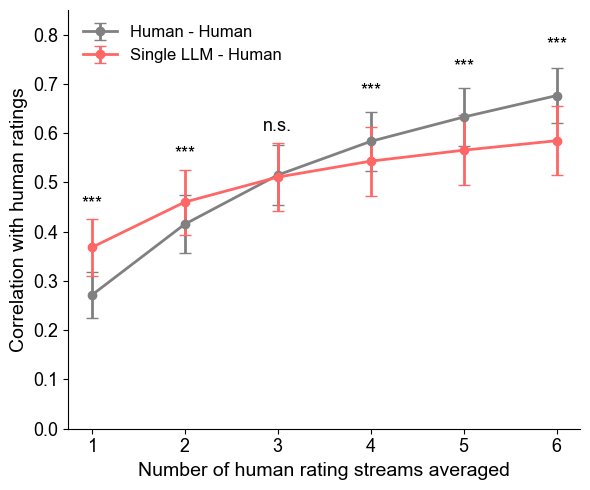

In [8]:
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

def fisher_r_to_z(r):
    r = np.clip(r, -0.999999, 0.999999)
    return 0.5 * np.log((1 + r) / (1 - r))

def fisher_z_to_r(z):
    return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

def corr(a, b):
    return np.corrcoef(a, b)[0, 1]

# ==================== Benjamini-Hochberg FDR ====================
def fdr_bh(pvals):
    """Benjamini-Hochberg FDR correction. Returns adjusted p-values."""
    pvals = np.asarray(pvals)
    n = len(pvals)
    if n == 0:
        return pvals
    sorted_idx = np.argsort(pvals)
    sorted_pvals = pvals[sorted_idx]
    
    # BH adjusted p-values
    adj_sorted = np.minimum.accumulate(sorted_pvals[::-1] * n / np.arange(n, 0, -1))[::-1]
    adj_sorted = np.clip(adj_sorted, 0, 1)
    
    adj_p = np.empty_like(pvals)
    adj_p[sorted_idx] = adj_sorted
    return adj_p

# ==================== Parameters ====================
rng = np.random.default_rng(42)
n_splits = 50
n_subjects = 12
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

# max subgroup size is 6 because Human-Human comparison needs two non-overlapping groups
group_sizes = np.arange(1, 7)

# Choose the single LLM used in the main analysis
single_llm_idx = 0   # 改成你的主分析 LLM index，比如 GPT-3.5

single_llm_ts = llm_danmu_all[:, :, single_llm_idx]          # [time, emotion]
avg_llm_ts = np.mean(llm_danmu_all, axis=2)                  # [time, emotion]

# Results: [group_size, emotion, split]
r_human_human = np.zeros((len(group_sizes), 6, n_splits))
r_single_llm_human = np.zeros((len(group_sizes), 6, n_splits))
r_avg_llm_human = np.zeros((len(group_sizes), 6, n_splits))

# ==================== Random subgroup analysis ====================
for gi, k in enumerate(group_sizes):
    for split in range(n_splits):
        subjects = rng.permutation(n_subjects)

        group_a = subjects[:k]
        group_b = subjects[k:2*k]

        for ei in range(6):
            human_a = human_danmu_12_aligned[:, ei, group_a].mean(axis=1)
            human_b = human_danmu_12_aligned[:, ei, group_b].mean(axis=1)

            # Human-Human consistency
            r_human_human[gi, ei, split] = corr(human_a, human_b)

            # Single LLM vs human subgroup
            r1 = corr(single_llm_ts[:, ei], human_a)
            r2 = corr(single_llm_ts[:, ei], human_b)
            r_single_llm_human[gi, ei, split] = fisher_z_to_r(
                np.mean([fisher_r_to_z(r1), fisher_r_to_z(r2)])
            )

            # Averaged LLMs vs human subgroup
            r1 = corr(avg_llm_ts[:, ei], human_a)
            r2 = corr(avg_llm_ts[:, ei], human_b)
            r_avg_llm_human[gi, ei, split] = fisher_z_to_r(
                np.mean([fisher_r_to_z(r1), fisher_r_to_z(r2)])
            )

# ==================== Statistical test with FDR ====================
z_human_human = fisher_r_to_z(r_human_human)
z_single_llm_human = fisher_r_to_z(r_single_llm_human)

raw_pvals = []
t_stats = []

for i in range(len(group_sizes)):
    t, p = stats.ttest_rel(z_human_human[i].reshape(-1), z_single_llm_human[i].reshape(-1))
    t_stats.append(t)
    raw_pvals.append(p)
    print(f"group_size={group_sizes[i]:d}: t={t:.3f}, raw_p={p:.4f}")

# FDR correction across the 6 group-size comparisons
adj_pvals = fdr_bh(raw_pvals)

print("\nAfter FDR correction:")
for i in range(len(group_sizes)):
    star = ''
    if adj_pvals[i] < 0.001:
        star = '***'
    elif adj_pvals[i] < 0.01:
        star = '**'
    elif adj_pvals[i] < 0.05:
        star = '*'
    print(f"group_size={group_sizes[i]:d}: adj_p={adj_pvals[i]:.4f} {star}")

# ==================== Summarize across emotions ====================
def summarize_over_emotions_and_splits(r_array):
    """
    r_array: [group_size, emotion, split]
    Returns mean and SEM across emotions.
    For each emotion, average over random splits using Fisher z.
    """
    z = fisher_r_to_z(r_array)
    emotion_mean_z = np.mean(z, axis=2)  # [group_size, emotion]
    mean_r = fisher_z_to_r(np.mean(emotion_mean_z, axis=1))
    sem_r = np.std(fisher_z_to_r(emotion_mean_z), axis=1, ddof=1) / np.sqrt(emotion_mean_z.shape[1])
    return mean_r, sem_r

mean_hh, sem_hh = summarize_over_emotions_and_splits(r_human_human)
mean_single, sem_single = summarize_over_emotions_and_splits(r_single_llm_human)
mean_avg, sem_avg = summarize_over_emotions_and_splits(r_avg_llm_human)

print(mean_single, mean_hh, mean_single-mean_hh)
print(sem_single, sem_hh)

# ==================== Plot ====================
matplotlib.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(6, 5))

ax.errorbar(
    group_sizes, mean_hh, yerr=sem_hh,
    marker='o', linewidth=2, capsize=4,
    label='Human - Human', color='gray'
)

ax.errorbar(
    group_sizes, mean_single, yerr=sem_single,
    marker='o', linewidth=2, capsize=4,
    label='Single LLM - Human', color='#ff6666'
)

ax.set_xlabel('Number of human rating streams averaged', fontsize=14)
ax.set_ylabel('Correlation with human ratings', fontsize=14)
ax.set_xticks(group_sizes)
ax.tick_params(axis='both', labelsize=13)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

ax.legend(
    fontsize=12,
    loc='upper left',
    frameon=False
)

# Significance markers above Single LLM - Human points
for i, x in enumerate(group_sizes):
    star = ''
    if adj_pvals[i] < 0.001:
        star = '***'
    elif adj_pvals[i] < 0.01:
        star = '**'
    elif adj_pvals[i] < 0.05:
        star = '*'
    else:
        star = 'n.s.'
    
    if star:
        # place slightly above the error bar of the Single LLM curve
        y_offset = 0.013
        y_pos = np.maximum(mean_single[i], mean_hh[i]) + sem_single[i] + y_offset
        ax.text(x, y_pos, star, ha='center', va='bottom', 
                fontsize=13, color='k')

plt.ylim([0, 0.85])
plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/subgroup_size_reliability_curve2.jpg', dpi=300, bbox_inches='tight')
plt.show()